In [1]:
import numpy as np
import numpy.typing as npt

In [2]:
# MATH SECTION
vec3 = npt.NDArray[np.float64]

def vec3_create(x : float = 0, y : float = 0, z : float = 0) -> vec3:
    return np.array([x, y, z], dtype=np.float64)

def dot(a : vec3, b : vec3) -> float:
    return np.dot(a, b)

def cross(a : vec3, b : vec3) -> vec3:
    return np.cross(a, b)

def magnitude(v : vec3) -> float:
    return np.linalg.norm(v)

#STRUCTURES
class Ball: #SIMPLE STRUCTURE TO HOLD BALL STATE
    def __init__(self, pos : vec3, vel : vec3, angular_vel : vec3):
        self.pos = pos
        self.trans_vel = vel
        self.angular_vel = angular_vel
        
class AABB: #AXIS ALIGNED BOUNDING BOX, FOR COLLISION DETECTION
    def __init__(self, min_bound : vec3, max_bound : vec3):
        self.min_bound = min_bound
        self.max_bound = max_bound
    

In [3]:
TABLE_LENGTH = 2.74 #m
TABLE_WIDTH  = 1.525 #m
GRAVITY = 9.81
BALL_RADIUS = 0.02
HZ = 30
TIME_STEP = 1 / HZ
MAX_VELOCITY = 50.0

world = {
    "TABLE" : AABB(vec3_create(-TABLE_WIDTH / 2, -0.1, -TABLE_LENGTH / 2), vec3_create(TABLE_WIDTH / 2,0,TABLE_LENGTH / 2)),
    "NET" : AABB(vec3_create(-TABLE_WIDTH / 2, 0, -0.01/2), vec3_create(TABLE_WIDTH / 2,0.15,0.01/2)),
    "FLOOR": AABB(vec3_create(-10, -10, -10), vec3_create(10, -1, 10)),
}

In [ ]:
def check_discrete_aabb_collision(pos : vec3, box: AABB):
    closest_point = np.maximum(box.min_bound, np.minimum(pos, box.max_bound))
    diff = pos - closest_point
    dist_squared = np.dot(diff, diff)

    if dist_squared >= (BALL_RADIUS * BALL_RADIUS):
        return False, None, 0.0

    distance = np.sqrt(dist_squared)

    if distance > 0.0001: 
        # Normalizamos el vector para obtener la dirección
        normal = diff / distance 
        penetration = BALL_RADIUS - distance
        return True, normal, penetration

    distances = [
        pos[0] - box.min_bound[0], # 0: Distancia a pared X Izquierda
        box.max_bound[0] - pos[0], # 1: Distancia a pared X Derecha
        pos[1] - box.min_bound[1], # 2: Distancia a pared Y Abajo (Suelo)
        box.max_bound[1] - pos[1], # 3: Distancia a pared Y Arriba (Techo)
        pos[2] - box.min_bound[2], # 4: Distancia a pared Z Atrás
        box.max_bound[2] - pos[2]  # 5: Distancia a pared Z Adelante
    ]

    min_dist = min(distances)
    min_index = distances.index(min_dist)

    normal = np.array([0.0, 0.0, 0.0])
    if min_index == 0:   normal[0] = -1.0
    elif min_index == 1: normal[0] = 1.0
    elif min_index == 2: normal[1] = -1.0
    elif min_index == 3: normal[1] = 1.0
    elif min_index == 4: normal[2] = -1.0
    elif min_index == 5: normal[2] = 1.0

    # La penetración total es el radio de la pelota MÁS lo que ya se hundió el centro
    penetration = BALL_RADIUS + min_dist
    return True, normal, penetration

def check_continuous_aabb_collision(prevPos : vec3, currentPos : vec3, box : AABB):
    expanded_min = box.min_bound - BALL_RADIUS
    expanded_max = box.max_bound + BALL_RADIUS

    origin = prevPos
    delta = currentPos - prevPos # Vector direccional del movimiento

    epsilon = 1e-8
    dir_safe = np.where(np.abs(delta) < epsilon, epsilon, delta)
    
    t0 = (expanded_min - origin) / dir_safe
    t1 = (expanded_max - origin) / dir_safe
    
    tmin_axis = np.minimum(t0, t1)
    tmax_axis = np.maximum(t0, t1)
    
    t_enter = np.max(tmin_axis)
    t_exit = np.min(tmax_axis)
    
    if t_enter <= t_exit and t_enter >= 0.0 and t_enter <= 1.0:
        hit_normal = np.array([0.0, 0.0, 0.0])
        if t_enter == tmin_axis[0]: # Chocó en el eje X (Pared izquierda o derecha)
            hit_normal[0] = -1.0 if delta[0] > 0 else 1.0
        elif t_enter == tmin_axis[1]: # Chocó en el eje Y (Piso o techo)
            hit_normal[1] = -1.0 if delta[1] > 0 else 1.0
        else: # Chocó en el eje Z (Pared frontal o trasera)
            hit_normal[2] = -1.0 if delta[2] > 0 else 1.0
        return True, t_enter, hit_normal
    return False, None, None

#struct for returning velocity results
class VelocityResult:
    def __init__(self):
        self.vel_low = 0
        self.vel_high = 0
        self.t_low = 0 #time of flight for low trajectory
        self.t_high = 0
        
    def __str__(self):
        return f"VelocityResult(vel_low={self.vel_low}, vel_high={self.vel_high})"
        

def get_velocity_to_hit_target(initial_pos : vec3, target_pos : vec3,speed : float, min_clearance_y : float =0.0) -> vec3:
    height_diff = target_pos[1] - initial_pos[1]
    horizontal_diff = vec3_create(target_pos[0] - initial_pos[0], 0, target_pos[2] - initial_pos[2])
    horizontal_distance = magnitude(horizontal_diff)
    v_0 = speed
    
    r = v_0**4 - GRAVITY * (GRAVITY * horizontal_distance**2 + 2 * height_diff * v_0**2)
    if r < 0:
        raise ValueError("Target is out of range for the given speed")
    
    r_sqrt = np.sqrt(r)
    d = GRAVITY * horizontal_distance
    theta_1 = np.arctan((v_0**2 + r_sqrt) / d)
    theta_2 = np.arctan((v_0**2 - r_sqrt) / d)
    theta_low = min(theta_1, theta_2)
    theta_high = max(theta_1, theta_2)
    azimuth = np.arctan2(horizontal_diff[2], horizontal_diff[0])
    
    def angles_to_velocity(theta, azimuth):
        v_y = v_0 * np.sin(theta)
        v_horizontal = v_0 * np.cos(theta)
        v_x = v_horizontal * np.cos(azimuth)
        v_z = v_horizontal * np.sin(azimuth)
        vec = vec3_create(v_x, v_y, v_z)
        vec[np.abs(vec) < 1e-10] = 0.0
        return vec
    
    r = VelocityResult()
    r.vel_low = angles_to_velocity(theta_low, azimuth)
    r.vel_high = angles_to_velocity(theta_high, azimuth)
    r.t_low = horizontal_distance / (v_0 * np.cos(theta_low))
    r.t_high = horizontal_distance / (v_0 * np.cos(theta_high))
    
    return r

#using the defined time takes to  get there apply the equations of motion to get the position at each time step and check for collisions with the net and the table, if any of the trajectories collide with the net or the table, we can discard it and use the other one, if both collide we can return an error or try to find a different speed or target point that is reachable without collisions.
def find_valid_trajectory(initial_pos : vec3, target_pos : vec3, speed : float, min_clearance_y : float = 0.0) -> vec3:
    #first compute
    r1 = get_velocity_to_hit_target(initial_pos, target_pos, speed, min_clearance_y)
    
    #now get the time and compute magnus effect
    r 
    
    #restriction for height when passing over the net, we want to make sure the ball passes above the net with at least min_clearance_y meters of clearance, this is a simple way to add a constraint to our trajectory
    # def check_z_cross(test_theta):
    #     if initial_pos[2] * target_pos[2] > 0:
    #         return True 
            
    #     z_dist = abs(target_pos[2] - initial_pos[2])
    #     if z_dist == 0:
    #         return True
            
    #     # Fracción del viaje horizontal total necesaria para llegar a Z=0
    #     fraction_to_z0 = abs(initial_pos[2]) / z_dist
    #     d_cross = horizontal_distance * fraction_to_z0
        
    #     # Calcular el tiempo que le toma llegar a esa distancia horizontal
    #     v_horiz = v_0 * np.cos(test_theta)
    #     t_cross = d_cross / v_horiz
        
    #     # Calcular la altura Y en ese preciso instante
    #     v_y_test = v_0 * np.sin(test_theta)
    #     y_cross = initial_pos[1] + (v_y_test * t_cross) - (0.5 * GRAVITY * t_cross**2)
        
    #     return y_cross >= min_clearance_y + BALL_RADIUS
    
    # def check_y_cross(test_theta, target_y):
    #     v_y = v_0 * np.sin(test_theta)
    #     a = 0.5 * GRAVITY
    #     b = -v_y
    #     c = target_y - initial_pos[1]
        
    #     discriminant = b**2 - 4 * a * c
    #     if discriminant < 0:
    #         return []
            
    #     sqrt_disc = np.sqrt(discriminant)
    #     t1 = (-b - sqrt_disc) / (2 * a)
    #     t2 = (-b + sqrt_disc) / (2 * a)
        
    #     v_horiz = v_0 * np.cos(test_theta)
    #     v_x = v_horiz * np.cos(azimuth)
    #     v_z = v_horiz * np.sin(azimuth)
        
    #     points = []
        
    #     for t in (t1, t2):
    #         if t >= 0:
    #             cross_x = initial_pos[0] + (v_x * t)
    #             cross_z = initial_pos[2] + (v_z * t)
    #             points.append(vec3_create(cross_x, target_y, cross_z))
                
    #     for point in points:
    #         hit,_,_ = check_discrete_aabb_collision(point, world["TABLE"])
    #         if (hit):
    #             return False
    
    #     return True

    # candidates_theta = [theta_low, theta_high]
    # azimuth = np.arctan2(horizontal_diff[2], horizontal_diff[0])
    
    
    # result = VelocityResult()
    # result.theta_low = theta_low
    # result.theta_high = theta_high
    # result.azimuth = azimuth
    
    # theta = None
    
    # for test_theta in candidates_theta:
    #     if not check_z_cross(test_theta):
    #         print(f"Trajectory with theta={test_theta:.2f} radians does not clear the net, skipping.")
    #         continue 
            
    #     if check_y_cross(test_theta, world["TABLE"].max_bound[1]) or check_y_cross(test_theta, world["TABLE"].min_bound[1]):
    #         print(f"Trajectory with theta={test_theta:.2f} radians collides with the table, skipping.")
    #         continue  
    #     theta = test_theta
    #     print(f"Found trayectory: {'Low (Fast)' if test_theta == theta_low else 'High (Safe)'}")
    #     break 

    # if theta is None:
    #     print("WARNING: No valid theta found that clears the net and doesn't collide with the table")
    #     theta = theta_low if check_z_cross(theta_low) else theta_high
    #     print(f"Using the theta angle: {theta:.2f} radians which is the lowest angle that reaches the target, but it may collide with the table or not clear the net.")




In [ ]:
def copy_ball(ball : Ball) -> Ball:
    return Ball(ball.pos.copy(), ball.trans_vel.copy(), ball.angular_vel.copy())

def update_ball(ball : Ball, t : float = 1.0):
    
    if (magnitude(ball.trans_vel) > MAX_VELOCITY):
        ball.trans_vel = ball.trans_vel * (MAX_VELOCITY / magnitude(ball.trans_vel))

    if (magnitude(ball.angular_vel) > (MAX_VELOCITY / 4)): #THE angular velocity is clamped to a quarter of the max velocity
        ball.angular_vel = ball.angular_vel * (MAX_VELOCITY / (magnitude(ball.angular_vel) * 4))
    
    MAGNUS_STRENGTH = 0.25
    g = vec3_create(0, -GRAVITY, 0)
    m = cross(ball.angular_vel,ball.trans_vel) * MAGNUS_STRENGTH
    a = g + m
    
    # RK2 (midpoint) integration
    mid_vel = ball.trans_vel + 0.5 * a * TIME_STEP * t
    ball.pos = ball.pos + mid_vel * TIME_STEP * t
    ball.trans_vel = ball.trans_vel + a * TIME_STEP * t
    
    
def resolve_bounce(ball : Ball, normal : vec3):
    #Do not lose energy to friction and bounce
    FRICTION_COEFF = 0.1
    BOUNCE_COEFF = 0.95
    #print(f"Resolving bounce with normal {(normal)}")
    vel_normal_mag = dot(ball.trans_vel, normal)
    #print(f"Resolving bounce: vel_normal_mag = {vel_normal_mag}")
    if vel_normal_mag >= -0.01:
        return
    vel_normal = normal * vel_normal_mag
    vel_tangent = ball.trans_vel - vel_normal  

    r_contact = -normal * BALL_RADIUS
    contact_vel_spin = cross(ball.angular_vel, r_contact)

    slip_vel = vel_tangent + contact_vel_spin
    delta_vel_tangent = -slip_vel * FRICTION_COEFF

    vel_tangent = vel_tangent + delta_vel_tangent
    vel_normal = -vel_normal * BOUNCE_COEFF
    
    ball.trans_vel = vel_tangent + vel_normal

def resolve_position_completely(ball, normal, penetration):
    ball.pos = ball.pos + normal * penetration

def check_and_solve_collision(world : dict, prev_ball : Ball, ball : Ball, verbose : bool = False):
    collided_names = []
    counter = 0
    MAX_COLLISION_ITERATIONS = 3
    for name, box in world.items():
        if counter >= MAX_COLLISION_ITERATIONS:
            if verbose:
                print("Reached maximum collision iterations, stopping further collision checks to prevent infinite loop.")
            break
        #first check using
        is_tunneling, t_impact, hit_normal = check_continuous_aabb_collision(prev_ball.pos, ball.pos, box)
        if is_tunneling:
            if verbose:
                print(f"Tunneling detected! t_impact={t_impact:.4f} WITH {name}")
            
            pb = copy_ball(prev_ball) # Reset ball to previous state
            update_ball(pb, t_impact) # Integrate only up to the point of impact
            resolve_bounce(pb, hit_normal) # Resolve the collision at the point of impact
            #now assign
            print(pb.trans_vel)
            ball.pos = pb.pos
            ball.trans_vel = pb.trans_vel
            if verbose:
                print(f"Ball velocity after resolving bounce: {ball.trans_vel}")
            #ball.angular_vel = pb.angular_vel
            collided_names.append(name)
            counter += 1
        else:
            #then check using discrete collision, this is more reliable at low speeds to avoid tunneling through the floor
            is_inside, normal, penetration = check_discrete_aabb_collision(ball.pos, box)
            if is_inside: #AT LOW SPEEDS, THIS IS MORE RELIABLE TO AVOID TUNNELING THROUGH THE FLOOR
                if verbose:
                    print("DISCRETE Collision with the floor detected!")
                resolve_position_completely(ball, normal, penetration)
                resolve_bounce(ball, normal)
                collided_names.append(name)
                counter += 1
                
        #check if last added is the net to HUGELY reduce the velocity
        if collided_names and collided_names[-1] == "NET":
            if verbose:
                print("Collided with the net, reducing velocity drastically to simulate the net's effect.")
            ball.trans_vel *= 0.1
            ball.angular_vel *= 0.1
                                
    return len(collided_names) > 0 , collided_names

def simulate_ball(ball : Ball, steps : int, target: vec3 = None) -> npt.NDArray[np.float64]:
    trajectory = []
    last_best_distance = float('inf')
    for _ in range(steps):

        prev_ball = copy_ball(ball)
        trajectory.append(ball.pos.copy())
        update_ball(ball)
        check_and_solve_collision(world,prev_ball, ball, verbose=True)
        #print(f"Ball vel: {ball.trans_vel}, Ball pos: {ball.pos}")
        #solve collisions with the world
        if target is not None:
            r = target - ball.pos
            r[1] = 0
            candidate = magnitude(r)
            if candidate < last_best_distance:
                last_best_distance = candidate
                print(f"New best distance to target: {last_best_distance:.4f} m")
            else:
                print(f"Distance to target: {candidate:.4f} m")
                break #stop the simulation if we start getting farther from the target, this is a simple heuristic to stop early if we miss the target
    return np.array(trajectory)

In [9]:
initial_pos = vec3_create(0, 0.2, 1.7) #start the ball half a meter above the table
target_pos = vec3_create(0.1, 0, 0.9) #we want to hit a target one meter in front of us at the same 
SPEED = 6
initial_spin = vec3_create(0, 0, 0)
#inital_spin = initial_spin * (SPEED / magnitude(initial_spin)) #we want the spin to be proportional to the speed, but not too much, so we scale it down by half

r = get_velocity_to_hit_target(initial_pos, target_pos,SPEED,0.15)
print(r)


ball = Ball(initial_pos, r.vel_low, initial_spin)
positions = simulate_ball(ball, HZ * 3) #100 steps
print(positions.shape)

VelocityResult(vel_low=[ 0.73740187 -0.80963048 -5.89921494], vel_high=[ 0.08007745  5.96516506 -0.6406196 ])
Tunneling detected! t_impact=0.7674 WITH TABLE
[ 0.66366168  1.93949317 -5.30929345]
Ball velocity after resolving bounce: [ 0.66366168  1.93949317 -5.30929345]
Tunneling detected! t_impact=0.8677 WITH TABLE
[ 0.59729551  1.8441861  -4.77836411]
Ball velocity after resolving bounce: [ 0.59729551  1.8441861  -4.77836411]
Tunneling detected! t_impact=0.3092 WITH FLOOR
[ 0.53756596  4.55707555 -4.30052769]
Ball velocity after resolving bounce: [ 0.53756596  4.55707555 -4.30052769]
Tunneling detected! t_impact=0.8758 WITH FLOOR
[ 0.48380937  4.33038974 -3.87047493]
Ball velocity after resolving bounce: [ 0.48380937  4.33038974 -3.87047493]
(90, 3)


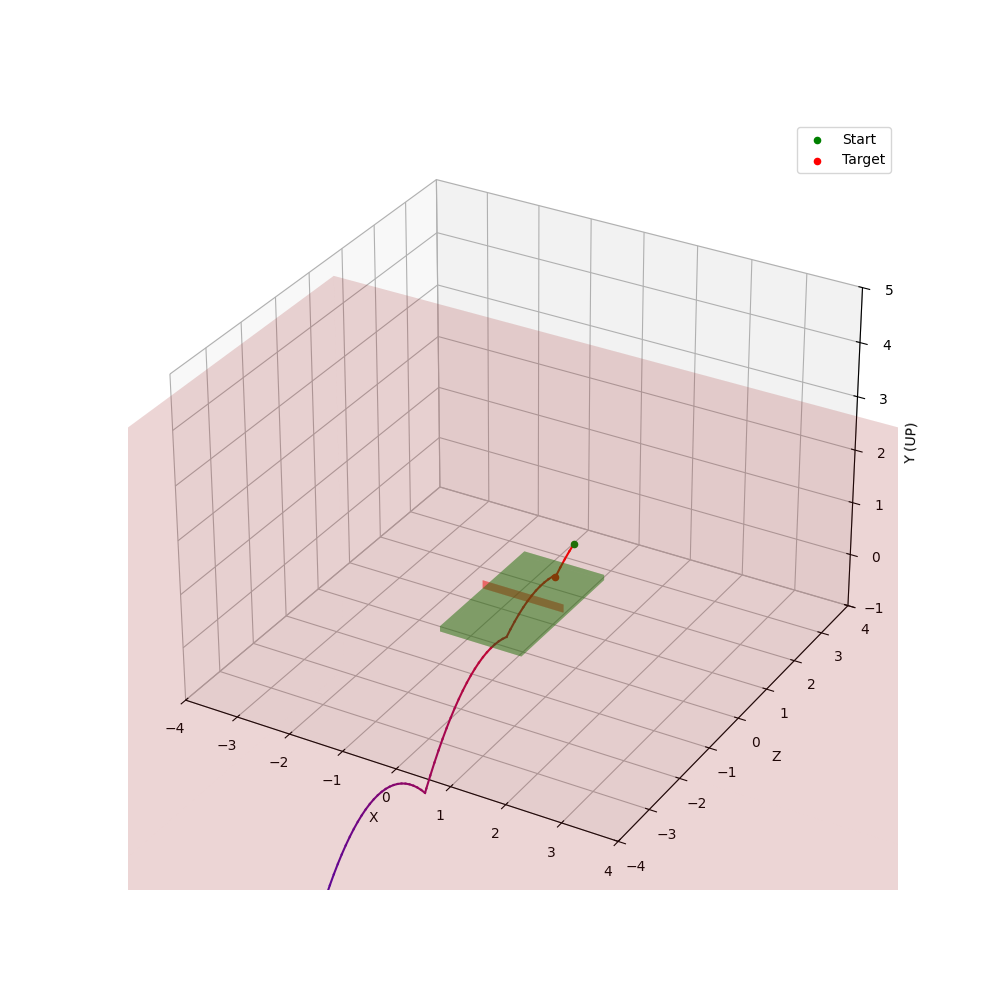

In [10]:
%matplotlib widget
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt

def draw_aabb_solid(ax, aabb : AABB, color='r', alpha=0.2):
    xmin, ymin, zmin = aabb.min_bound
    xmax, ymax, zmax = aabb.max_bound

    faces = [
        # abajo
        [(xmin,ymin,zmin), (xmax,ymin,zmin), (xmax,ymax,zmin), (xmin,ymax,zmin)],
        # arriba
        [(xmin,ymin,zmax), (xmax,ymin,zmax), (xmax,ymax,zmax), (xmin,ymax,zmax)],
        # lados
        [(xmin,ymin,zmin), (xmax,ymin,zmin), (xmax,ymin,zmax), (xmin,ymin,zmax)],
        [(xmin,ymax,zmin), (xmax,ymax,zmin), (xmax,ymax,zmax), (xmin,ymax,zmax)],
        [(xmin,ymin,zmin), (xmin,ymax,zmin), (xmin,ymax,zmax), (xmin,ymin,zmax)],
        [(xmax,ymin,zmin), (xmax,ymax,zmin), (xmax,ymax,zmax), (xmax,ymin,zmax)],
    ]

    faces_swapped = [
        [(x, z, y) for (x,y,z) in face]
        for face in faces
    ]

    box = Poly3DCollection(faces_swapped, alpha=alpha, facecolor=color)
    ax.add_collection3d(box)

def plot_trajectory(positions : npt.NDArray[np.float32]):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    #ax.plot(positions[:,0], positions[:,2], positions[:,1])
    
    #change color according to t from [0,1] where 0 is the start and 1 is the end of the trajectory
    for i in range(len(positions)-1):
        t = i / (len(positions)-1)
        ax.plot(positions[i:i+2,0], positions[i:i+2,2], positions[i:i+2,1], color=(1-t, 0, t))
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y (UP)')
    
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    ax.set_zlim(-1,5)
    
    draw_aabb_solid(ax, world["TABLE"], color='green', alpha=0.3)
    draw_aabb_solid(ax, world["NET"], color='red', alpha=0.3)
    draw_aabb_solid(ax, world["FLOOR"], color='brown', alpha=0.1)
    
    
    #add start and target points
    ax.scatter(initial_pos[0], initial_pos[2], initial_pos[1], color='green', label='Start')
    ax.scatter(target_pos[0], target_pos[2], target_pos[1], color='red', label='Target')
    ax.legend()
    
    plt.show()
    
plot_trajectory(positions)

In [162]:
import torch

SIZE_INPUT = 1
SIZE_OUTPUT = 1
INNER_SIZE = 2
N_LAYERS = 2
class myModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(SIZE_INPUT, INNER_SIZE))
        for _ in range(N_LAYERS-1):
            self.layers.append(torch.nn.Linear(INNER_SIZE, INNER_SIZE))
        self.layers.append(torch.nn.Linear(INNER_SIZE, SIZE_OUTPUT))
        
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.nn.functional.gelu(layer(x))
        return self.layers[-1](x)
m = myModel()
x = torch.tensor([0.1])
y = m(x)
print(y)

tensor([-0.1091], grad_fn=<ViewBackward0>)


In [163]:
#make data to learn a non linear function like
import torch

def f(x):
    return torch.sin(x * 2 * np.pi) + 0.5 * torch.sin(x * 4 * np.pi) + 0.25 * torch.sin(x * 8 * np.pi)


def train (model, x_train, y_train, epochs=2000, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(x_train)
        loss = loss_fn(outputs, y_train)
        
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}", end='\r')

x_train = torch.linspace(0, 1, 256).unsqueeze(1)
y_train = f(x_train).float()
train(m, x_train, y_train)

C:\Users\andre\AppData\Local\Temp\ipykernel_18644\4005632699.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(f(x_test)).float()


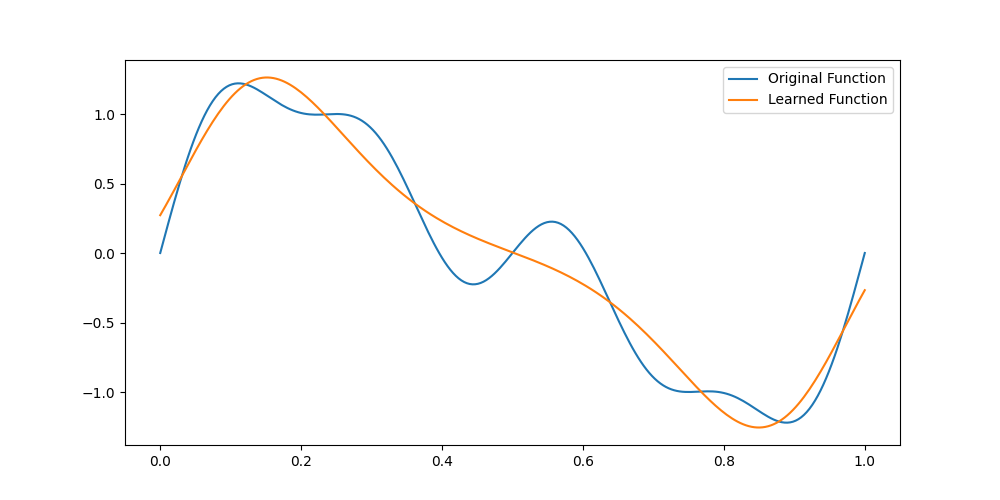

In [164]:
#plot the original vs the learned function
x_test = torch.linspace(0, 1, 256).unsqueeze(1)
y_test = torch.tensor(f(x_test)).float()
y_pred = m(x_test).detach()
plt.figure(figsize=(10,5))
plt.plot(x_test.numpy(), y_test.numpy(), label='Original Function')
plt.plot(x_test.numpy(), y_pred.numpy(), label='Learned Function')
plt.legend()